Name: Anuj Prasad Pradhan

StudentID: 2408570

# 6CS012 Final Portfolio Project — Part 2
## Image Classification with CNNs and Transfer Learning

This notebook is divided into two main parts:
- **Part A** — Designing, training, and evaluating CNN models from scratch (Baseline, Deeper, SGD vs Adam, Ablation Study)
- **Part B** — Fine-tuning a pre-trained MobileNetV2 model using Transfer Learning

At the end, a **Comparative Analysis** benchmarks all models against each other.

**Dataset:** Insect Classification (multi-class image dataset)


---
# Part A: Designing and Analysing CNNs from Scratch

This section covers end-to-end CNN development: data exploration, baseline modelling, a deeper regularised architecture, optimizer comparison, and an ablation study.

## Section 1 — Library Imports

All required libraries are imported here. TensorFlow/Keras is used for model building and training; scikit-learn for evaluation metrics; matplotlib and seaborn for visualisation.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import random
from PIL import Image
import time

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

## Section 2 — Dataset Paths

The dataset is stored on Google Drive and accessed via mounted paths. The dataset consists of insect images organised into class subdirectories for training and testing.

In [ ]:
test_dir = "/content/drive/Shareddrives/AI/Insect Classification/test"
train_dir = "/content/drive/Shareddrives/AI/Insect Classification/train"

---
## Section 3 — Data Understanding, Analysis, and Visualisation

 This section explores:
- The available class labels
- Data integrity (corrupted images)
- Class distribution and balance
- Visual samples from each class

### 3.1 Dataset Description

The dataset contains images of insects across multiple categories. Each subdirectory within the training folder corresponds to one insect class. Images vary in size and are resized during preprocessing.

### 3.2 Discovering Class Labels

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 9 classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


### 3.3 Data Integrity Check — Identifying Corrupted Images

Corrupted images can silently cause training failures or degrade model accuracy. The following cell scans every image using PIL's `verify()` method and removes any that cannot be opened cleanly.

In [ ]:
corrupted = []

for cls in class_names:
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


### 3.4 Class Distribution

Understanding class balance is critical. Highly imbalanced datasets can bias a model towards the majority class. The table below shows the number of valid images per class.

In [ ]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
aphids                               253
armyworm                             210
beetle                               277
bollworm                             226
grasshopper                          262
mites                                230
mosquito                             280
sawfly                               185
stem_borer                           167


### 3.5 Sample Image Visualisation

One random image is selected from each class and displayed in a grid. This gives a qualitative sense of the visual variation within the dataset.

In [ ]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

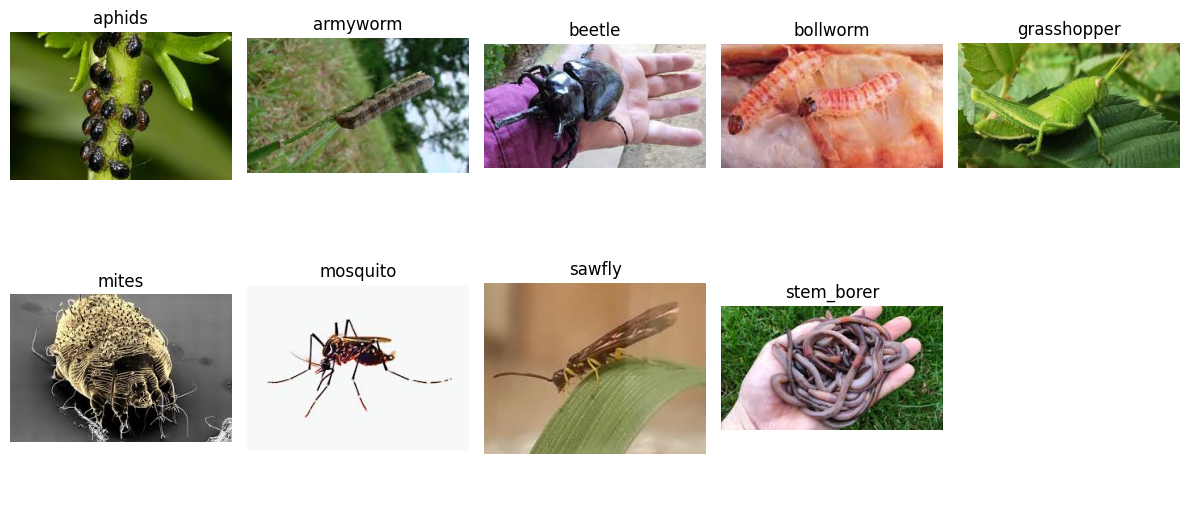

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

---
## Section 4 — Data Preprocessing and Augmentation

### 4.1 Hyperparameters

Key global hyperparameters are defined here:
- `IMG_SIZE = 128` — All images are resized to 128×128 pixels for Part A
- `BATCH_SIZE = 32` — Balances GPU memory usage and gradient stability

### 4.2 Data Generators

`keras.utils.image_dataset_from_directory` is used to load images directly from the folder structure. The training data is split 80/20 into training and validation subsets using `validation_split=0.2` with a fixed `seed=42` for reproducibility.

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [ ]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=20,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     validation_split=0.2
# )

# test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2090 files belonging to 9 classes.
Using 1672 files for training.
Found 2090 files belonging to 9 classes.
Using 418 files for validation.
Found 384 files belonging to 9 classes.


### 4.3 Data Augmentation

Data augmentation artificially increases dataset diversity by applying random transformations during training. This helps the model generalise and reduces overfitting. The following augmentation techniques are applied:
- **RandomFlip** — horizontal mirroring
- **RandomRotation** — up to ±10% rotation
- **RandomZoom** — up to 20% zoom
- **RandomContrast** — up to 10% contrast adjustment

These layers are embedded directly in the model pipeline so augmentation only happens during training.

In [ ]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
]

### 4.4 Augmented Image Samples

The cell below visualises the effect of the augmentation pipeline on sample training images.

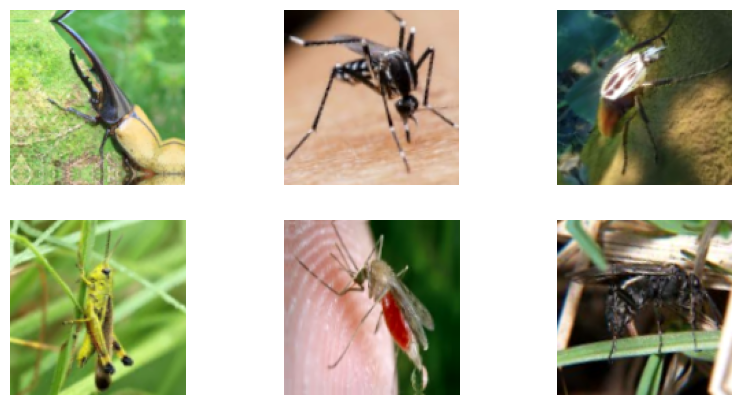

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,5))
    for i in range(6):
        ax = plt.subplot(2,3,i+1)
        augmented = images[i]
        for layer in data_augmentation_layers:
            augmented = layer(augmented)
        plt.imshow(augmented.numpy().astype("uint8"))
        plt.axis("off")

### 4.5 Pixel Normalisation

A `Rescaling(1./255)` layer converts raw pixel values from [0, 255] to [0.0, 1.0]. This is included inside the model definition to keep the full preprocessing pipeline self-contained.

In [ ]:
normalization_layer = layers.Rescaling(1./255)

---
## Section 5 — Baseline CNN Model

**Design Choices:**
- ReLU activations introduce non-linearity while avoiding the vanishing gradient problem
- MaxPooling halves spatial dimensions at each block, progressively extracting higher-level features
- Three fully connected layers allow complex decision boundaries before the final classification
- No regularisation (dropout/batch norm) is intentional — this keeps the baseline simple for later comparison

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Use the already defined classNames from os.listdir(train_dir)
# num_classes = len(train_ds.classNames) # Original problematic line

baseline_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    *data_augmentation_layers,

    normalization_layer,

    # CNN Layers
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

### 5.2 Model Compilation and Summary

The model is compiled using the **Adam optimiser** with a learning rate of `0.0005`. Sparse categorical crossentropy is used as the loss function since labels are integer-encoded (not one-hot).

In [ ]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,315,273 (12.65 MB)

 Trainable params: 3,315,273 (12.65 MB)

 Non-trainable params: 0 (0.00 B)

### 5.3 Training the Baseline Model

**Callbacks used:**
- `EarlyStopping` (patience=5) — halts training when validation loss stops improving, restoring the best weights
- `ReduceLROnPlateau` (patience=3, factor=0.5) — halves the learning rate when validation loss plateaus, helping escape local minima

The model is trained for up to 20 epochs.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [ ]:
baseline_start_time = time.time()
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop, lr_scheduler]
)
baseline_end_time = time.time()
print(f"Training Time: {baseline_end_time - baseline_start_time} seconds")

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 187ms/step - accuracy: 0.1746 - loss: 2.1480 - val_accuracy: 0.2632 - val_loss: 2.0601 - learning_rate: 5.0000e-04
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.3086 - loss: 1.9305 - val_accuracy: 0.3469 - val_loss: 1.7674 - learning_rate: 5.0000e-04
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 223ms/step - accuracy: 0.3917 - loss: 1.7254 - val_accuracy: 0.3589 - val_loss: 1.6523 - learning_rate: 5.0000e-04
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.4779 - loss: 1.5011 - val_accuracy: 0.4761 - val_loss: 1.6273 - learning_rate: 5.0000e-04
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.5102 - loss: 1.4040 - val_accuracy: 0.5024 - val_loss: 1.5171 - learning_rate: 5.0000e-04
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - accuracy: 0.5682 - loss: 1.2435 - val_accuracy: 0.5359 - val_loss: 1.3134 - learning_rate: 5.0000e-04
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - accu

### 5.4 Training Curves

The plots below show accuracy and loss across epochs for both the training and validation sets. A growing gap between the two curves indicates overfitting.

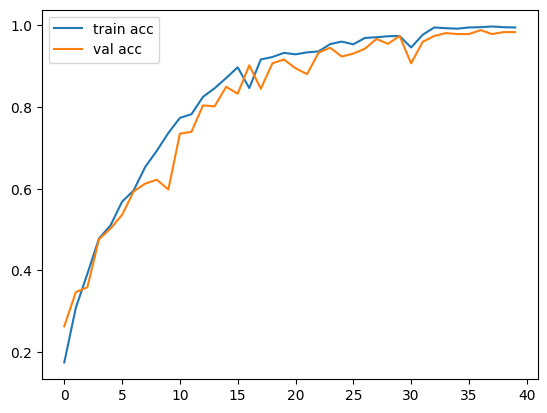

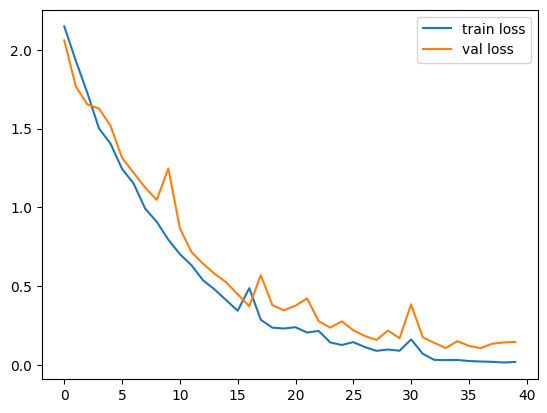

In [ ]:
plt.plot(history_baseline.history['accuracy'], label='train acc')
plt.plot(history_baseline.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_baseline.history['loss'], label='train loss')
plt.plot(history_baseline.history['val_loss'], label='val loss')
plt.legend()
plt.show()

### 5.5 Baseline Model Evaluation

The model is evaluated on the held-out test set. Precision, recall, and F1-score are reported per class, providing a more depth view than accuracy alone

In [ ]:
baseline_loss, baseline_acc = baseline_model.evaluate(test_ds)
print("Test Accuracy:", baseline_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 59s 5s/step - accuracy: 0.9427 - loss: 0.5070
Test Accuracy: 0.9427083134651184


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = baseline_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)


print(classification_report(y_true, y_pred, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step
              precision    recall  f1-score   support

      aphids       0.92      1.00      0.96        44
    armyworm       0.91      0.93      0.92        43
      beetle       0.98      0.96      0.97        50
    bollworm       1.00      0.94      0.97        36
 grasshopper       0.90      0.96      0.93        46
       mites       0.90      0.90      0.90        42
    mosquito       1.00      0.98      0.99        50
      sawfly       0.94      0.86      0.90        37
  stem_borer       0.94      0.92      0.93        36

    accuracy                           0.94       384
   macro avg       0.94      0.94      0.94       384
weighted avg       0.94      0.94      0.94       384



### 5.6 Confusion Matrix

The confusion matrix reveals which classes are most frequently misclassified and which pairs of classes are most easily confused by the model.

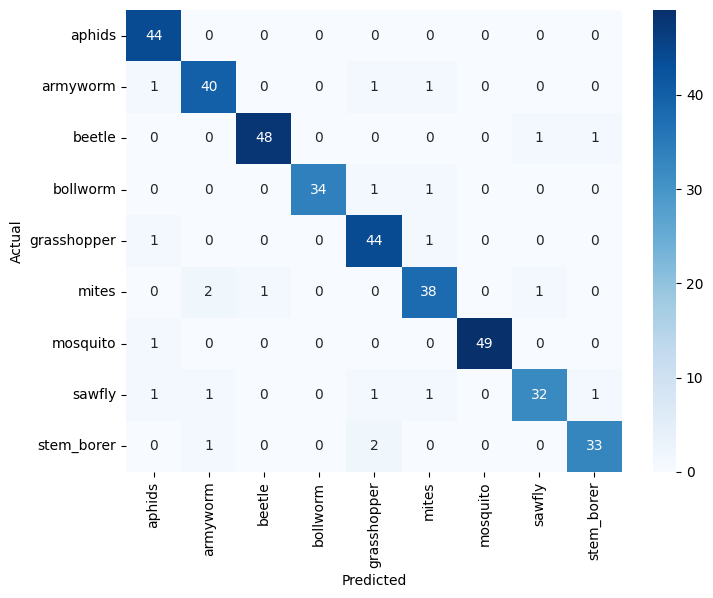

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---
## Section 6 — Deeper CNN Architecture with Regularisation



In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(train_ds.class_names)

deep_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    *data_augmentation_layers,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(num_classes, activation='softmax')
])





### 6.2 Model Compilation and Summary

The deeper model uses **Adam** with a slightly higher learning rate (`0.001`) and is trained for up to 40 epochs.

In [ ]:
deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,978,729 (11.36 MB)

 Trainable params: 2,977,257 (11.36 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [ ]:
deep_start_time = time.time()

history_deep = deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop, lr_scheduler]
)

deep_end_time = time.time()

print(f"Training Time: {deep_end_time - deep_start_time} seconds")

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - accuracy: 0.2733 - loss: 2.1637 - val_accuracy: 0.1005 - val_loss: 3.8086 - learning_rate: 0.0010
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 286ms/step - accuracy: 0.4091 - loss: 1.7081 - val_accuracy: 0.1077 - val_loss: 3.7339 - learning_rate: 0.0010
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.4270 - loss: 1.6118 - val_accuracy: 0.0789 - val_loss: 4.9802 - learning_rate: 0.0010
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.4683 - loss: 1.5202 - val_accuracy: 0.1268 - val_loss: 4.1333 - learning_rate: 0.0010
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.5538 - loss: 1.2874 - val_accuracy: 0.2201 - val_loss: 3.3601 - learning_rate: 0.0010
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.6232 - loss: 1.1075 - val_accuracy: 0.2321 - val_loss: 3.0365 - learning_rate: 0.0010
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.6340 - loss: 1.0

### 6.3 Training Curves — Deeper Model

Comparing these curves against the baseline curves reveals whether the added depth and regularisation help close the train/validation gap.

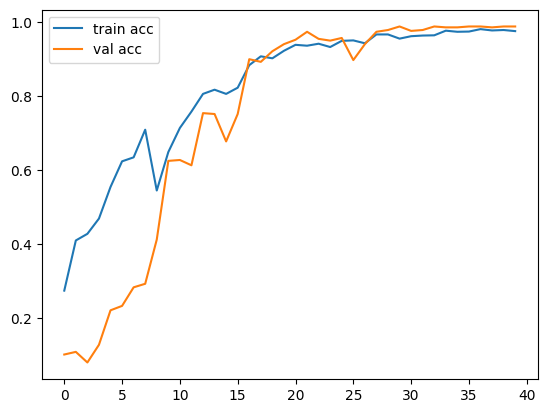

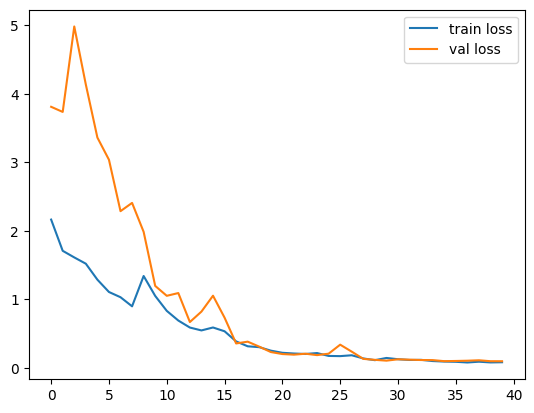

In [ ]:
plt.plot(history_deep.history['accuracy'], label='train acc')
plt.plot(history_deep.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_deep.history['loss'], label='train loss')
plt.plot(history_deep.history['val_loss'], label='val loss')
plt.legend()
plt.show()

### 6.4 Deeper Model Evaluation

The same evaluation protocol as the baseline is used to enable a direct comparison.

In [ ]:
deep_loss, deep_acc = deep_model.evaluate(test_ds)
print("Test Accuracy:", deep_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.9505 - loss: 0.2495
Test Accuracy: 0.9505208134651184


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = deep_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

# classNames is already defined globally from os.listdir(train_dir)
# classNames = test_ds.classNames

print(classification_report(y_true, y_pred, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step
              precision    recall  f1-score   support

      aphids       0.86      1.00      0.93        44
    armyworm       0.95      0.86      0.90        43
      beetle       0.98      0.96      0.97        50
    bollworm       0.97      1.00      0.99        36
 grasshopper       0.96      0.96      0.96        46
       mites       0.93      0.95      0.94        42
    mosquito       1.00      1.00      1.00        50
      sawfly       0.94      0.86      0.90        37
  stem_borer       0.97      0.94      0.96        36

    accuracy                           0.95       384
   macro avg       0.95      0.95      0.95       384
weighted avg       0.95      0.95      0.95       384



---
## Section 7 — Optimizer Comparison: SGD vs Adam

Optimizer choice has a significant impact on convergence speed and final model performance. This section trains the same deeper architecture using two optimizers:

| Optimizer | Strategy | Key Hyperparameters |
|-----------|----------|--------------------|
| **Adam** | Adaptive learning rates per parameter | lr=0.001, β₁=0.9, β₂=0.999 |
| **SGD** | Fixed learning rate with momentum | lr=0.01, momentum=0.9, Nesterov=True |

**Adam** typically converges faster due to adaptive learning rates. **SGD with Nesterov momentum** can generalise better in some cases but requires more epochs to converge.

### 7.1 Deeper Model with SGD Optimizer

In [ ]:
from tensorflow.keras.optimizers import SGD

deep_model_sgd = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    *data_augmentation_layers,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(num_classes, activation='softmax')
])




deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_model_sgd.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,978,729 (11.36 MB)

 Trainable params: 2,977,257 (11.36 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [ ]:
history_sgd = deep_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 207ms/step - accuracy: 0.2524 - loss: 2.2026 - val_accuracy: 0.1053 - val_loss: 41.9298 - learning_rate: 0.0100
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - accuracy: 0.3666 - loss: 1.8003 - val_accuracy: 0.1890 - val_loss: 5.0965 - learning_rate: 0.0100
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.4234 - loss: 1.6144 - val_accuracy: 0.2656 - val_loss: 2.4006 - learning_rate: 0.0100
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.4946 - loss: 1.4830 - val_accuracy: 0.4426 - val_loss: 1.6874 - learning_rate: 0.0100
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.5251 - loss: 1.3622 - val_accuracy: 0.4976 - val_loss: 1.5407 - learning_rate: 0.0100
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 198ms/step - accuracy: 0.5461 - loss: 1.2894 - val_accuracy: 0.4809 - val_loss: 1.5557 - learning_rate: 0.0100
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - accuracy: 0.5951 - loss: 1.

### 7.2 SGD Training Curves

Compare convergence speed and smoothness against the Adam-trained deeper model above.

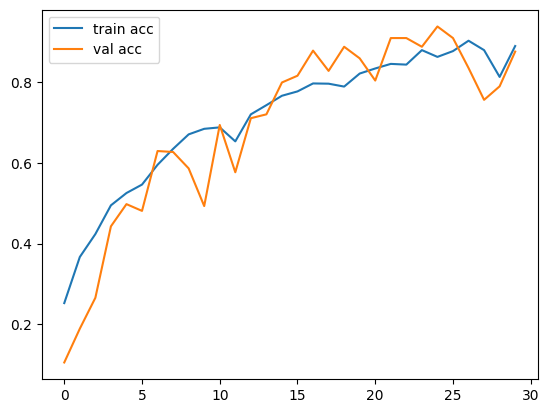

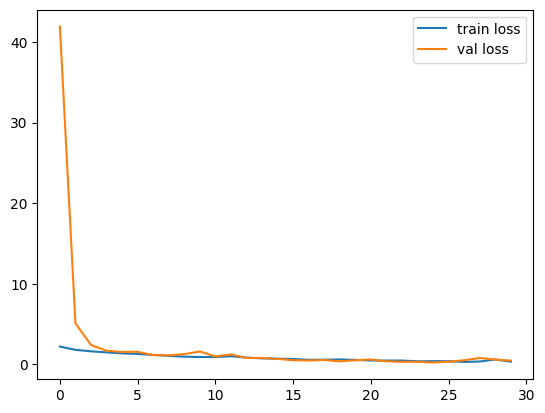

In [ ]:
plt.plot(history_sgd.history['accuracy'], label='train acc')
plt.plot(history_sgd.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_sgd.history['loss'], label='train loss')
plt.plot(history_sgd.history['val_loss'], label='val loss')
plt.legend()
plt.show()

### 7.3 SGD Model Evaluation

In [ ]:
deep_sgd_loss, deep_sgd_acc = deep_model_sgd.evaluate(test_ds)
print("Test Accuracy:", deep_sgd_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.9297 - loss: 0.2883
Test Accuracy: 0.9296875


Model Comparison:


,Model,Test Accuracy,Test Loss
0,Deep Model (ADAM),0.950521,0.249481
1,Deep Model (SGD),0.929688,0.288256


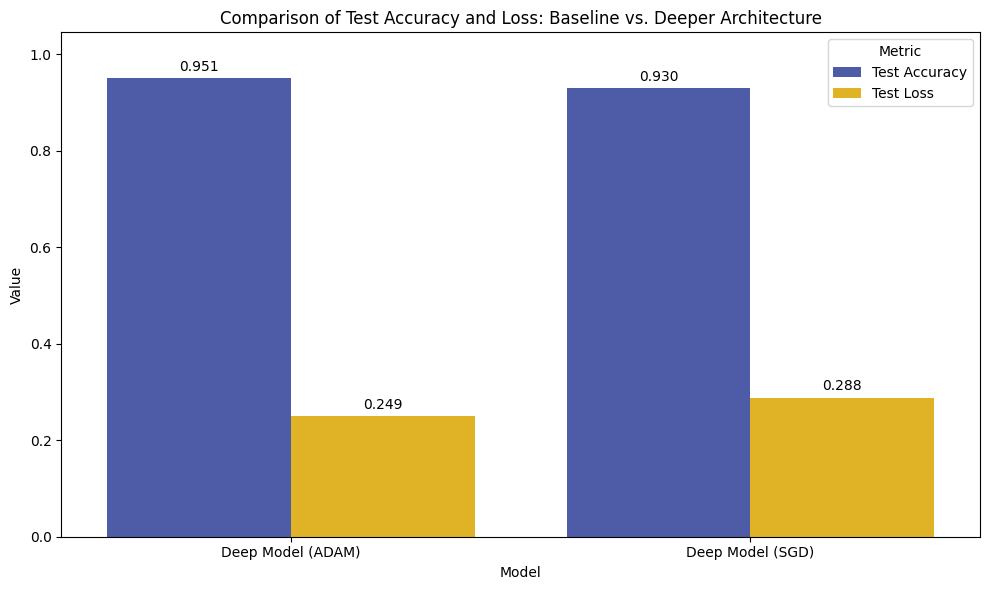

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

comparison_metrics = {
    'Model': ['Deep Model (ADAM)', "Deep Model (SGD)"],
    'Test Accuracy': [deep_acc, deep_sgd_acc],
    'Test Loss': [deep_loss, deep_sgd_loss],
}

comparison_df = pd.DataFrame(comparison_metrics)
print("Model Comparison:")
display(comparison_df)

# Reshape the DataFrame for plotting
comparison_melted = comparison_df.melt(
    id_vars='Model',
    value_vars=['Test Accuracy', 'Test Loss'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_melted,
    x='Model',
    y='Value',
    hue='Metric',
     palette=['#3F51B5', '#FFC107']
)

plt.title('Comparison of Test Accuracy and Loss: Adam vs. SGD Architecture')
plt.ylabel('Value')
plt.ylim(0, max(comparison_melted['Value']) * 1.1) # Add some padding to y-axis

# Add value labels on bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f', padding=3)

plt.legend(title='Metric')
plt.tight_layout()
plt.show()

---
## Section 8 — Ablation Study: Removing Dropout

An ablation study isolates the contribution of individual components by systematically removing them and measuring the impact on performance. Here, **Dropout is removed** from the deeper architecture while keeping all other components (Batch Normalisation, depth, filters) identical.



In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(train_ds.class_names)

# Deeper model without Dropout — used for ablation study
ablation_model_no_dropout = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    *data_augmentation_layers,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

ablation_model_no_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ablation_model_no_dropout.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     2,359,55

 Total params: 2,978,729 (11.36 MB)

 Trainable params: 2,977,257 (11.36 MB)

 Non-trainable params: 1,472 (5.75 KB)

### 8.1 Training the Ablation Model

The same callbacks and training configuration are used to ensure a fair comparison with the full deeper model.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

ablation_early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ablation_lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history_ablation_no_dropout = ablation_model_no_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[ablation_early_stop, ablation_lr_scheduler]
)

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.6035 - loss: 1.1231 - val_accuracy: 0.0861 - val_loss: 5.4778 - learning_rate: 2.5000e-04
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.7685 - loss: 0.7656 - val_accuracy: 0.0861 - val_loss: 6.0349 - learning_rate: 2.5000e-04
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 204ms/step - accuracy: 0.8236 - loss: 0.6071 - val_accuracy: 0.0861 - val_loss: 5.9479 - learning_rate: 2.5000e-04
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.8666 - loss: 0.4885 - val_accuracy: 0.0861 - val_loss: 7.8022 - learning_rate: 2.5000e-04
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - accuracy: 0.9151 - loss: 0.3327 - val_accuracy: 0.0933 - val_loss: 6.4429 - learning_rate: 1.2500e-04
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 203ms/step - accuracy: 0.9426 - loss: 0.2571 - val_accuracy: 0.1148 - val_loss: 4.2546 - learning_rate: 1.2500e-04
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accur

### 8.2 Ablation Training Curves

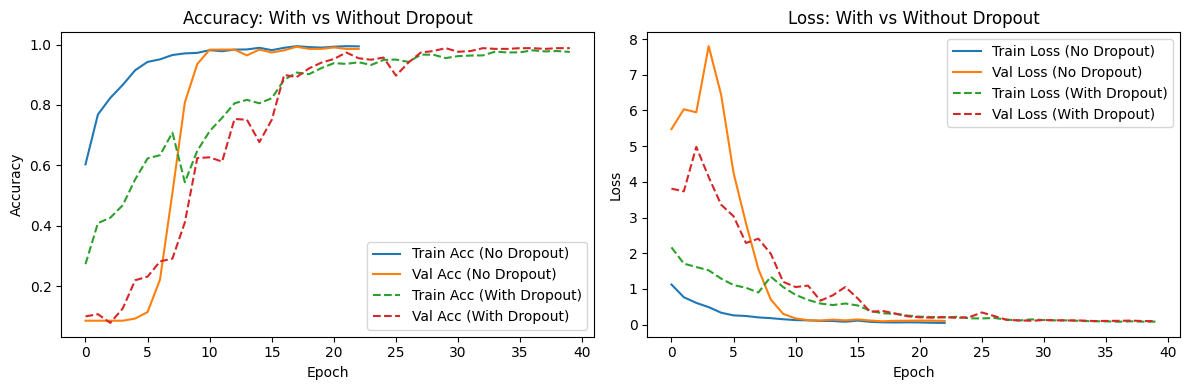

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_ablation_no_dropout.history['accuracy'], label='Train Acc (No Dropout)')
plt.plot(history_ablation_no_dropout.history['val_accuracy'], label='Val Acc (No Dropout)')
plt.plot(history_deep.history['accuracy'], label='Train Acc (With Dropout)', linestyle='--')
plt.plot(history_deep.history['val_accuracy'], label='Val Acc (With Dropout)', linestyle='--')
plt.title('Accuracy: With vs Without Dropout')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ablation_no_dropout.history['loss'], label='Train Loss (No Dropout)')
plt.plot(history_ablation_no_dropout.history['val_loss'], label='Val Loss (No Dropout)')
plt.plot(history_deep.history['loss'], label='Train Loss (With Dropout)', linestyle='--')
plt.plot(history_deep.history['val_loss'], label='Val Loss (With Dropout)', linestyle='--')
plt.title('Loss: With vs Without Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 8.3 Ablation Model Evaluation

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true_ablation = []
for images, labels in test_ds:
    y_true_ablation.extend(labels.numpy())
y_true_ablation = np.array(y_true_ablation)

ablation_predictions = ablation_model_no_dropout.predict(test_ds)
y_pred_ablation = np.argmax(ablation_predictions, axis=1)

# classNames is already defined globally from os.listdir(train_dir)
print("=== Ablation Model (No Dropout) — Classification Report ===")
print(classification_report(y_true_ablation, y_pred_ablation, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step
=== Ablation Model (No Dropout) — Classification Report ===
              precision    recall  f1-score   support

      aphids       0.86      1.00      0.93        44
    armyworm       0.95      0.93      0.94        43
      beetle       0.98      0.98      0.98        50
    bollworm       0.97      1.00      0.99        36
 grasshopper       0.94      0.98      0.96        46
       mites       0.97      0.90      0.94        42
    mosquito       1.00      0.98      0.99        50
      sawfly       0.97      0.89      0.93        37
  stem_borer       1.00      0.94      0.97        36

    accuracy                           0.96       384
   macro avg       0.96      0.96      0.96       384
weighted avg       0.96      0.96      0.96       384



### 8.4 Ablation Study Findings

- **Without Dropout**, the model is expected to overfit more quickly, with training accuracy significantly exceeding validation accuracy
- The train/validation gap should be visibly wider compared to the full deeper model
- This confirms that Dropout acts as an effective regulariser, constraining the model's capacity to memorise training examples
- Batch Normalisation alone is not sufficient to prevent overfitting when training data is limited

---
# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

**Selected Model: MobileNetV2**

The transfer learning process follows two phases:
1. **Feature Extraction** — freeze the convolutional base, train only the new classification head
2. **Fine-Tuning** — unfreeze the top layers of the base model and train end-to-end with a lower learning rate

## Section 9 — Data Loading

MobileNetV2 expects **224×224 pixel inputs** (matching its ImageNet training dimensions). The dataset is reloaded with this new image size. The augmentation pipeline from Part A is reused.

In [ ]:
IMG_SIZE = 224

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    shuffle=False
)

Found 2090 files belonging to 9 classes.
Using 1672 files for training.
Found 2090 files belonging to 9 classes.
Using 418 files for validation.
Found 384 files belonging to 9 classes.


## Section 10 — Phase 1: Feature Extraction

### 10.1 Loading the Pre-Trained Base Model

MobileNetV2 is loaded with `include_top=False` to remove the original 1000-class ImageNet classifier. The `weights='imagenet'` argument loads the pre-trained weights.

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,   # Remove original classifier
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

### 10.2 Classification Head Architecture



> The convolutional base is **frozen** — only the classification head is updated during this phase.

In [ ]:
num_classes = len(train_ds.class_names)

model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    *data_augmentation_layers,

    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

### 10.3 Compilation and Model Summary

A moderate learning rate (`0.0005`) is used — too high a rate risks destroying the pre-trained features during head training.

In [ ]:
model.compile(
    # optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,233 (9.26 MB)

 Trainable params: 167,689 (655.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

### 10.4 Training — Feature Extraction Phase

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - accuracy: 0.4868 - loss: 1.6290 - val_accuracy: 0.7033 - val_loss: 0.9389 - learning_rate: 5.0000e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 206ms/step - accuracy: 0.7374 - loss: 0.7889 - val_accuracy: 0.8541 - val_loss: 0.5711 - learning_rate: 5.0000e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.8283 - loss: 0.5104 - val_accuracy: 0.9019 - val_loss: 0.3855 - learning_rate: 5.0000e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.8630 - loss: 0.3964 - val_accuracy: 0.9282 - val_loss: 0.2806 - learning_rate: 5.0000e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step - accuracy: 0.8911 - loss: 0.3252 - val_accuracy: 0.9450 - val_loss: 0.2381 - learning_rate: 5.0000e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.9121 - loss: 0.2791 - val_accuracy: 0.9498 - val_loss: 0.2069 - learning_rate: 5.0000e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - acc

### 10.5 Feature Extraction Training Curves

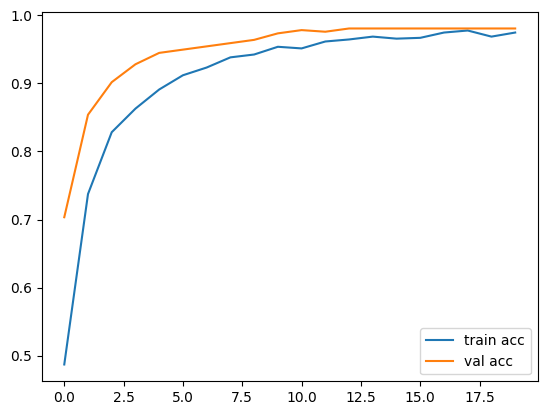

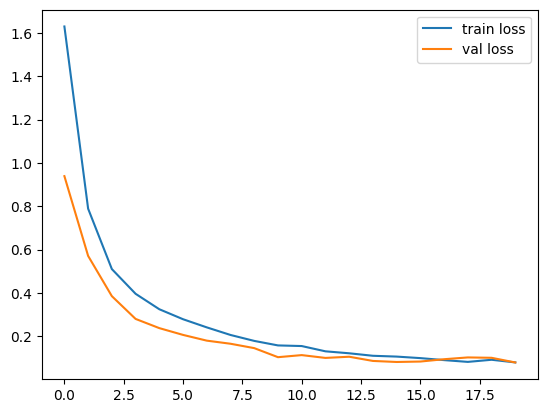

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

### 10.6 Evaluation — Feature Extraction Phase

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

# classNames is already defined globally from os.listdir(train_dir)
# classNames = test_ds.classNames

print(classification_report(y_true, y_pred, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step
              precision    recall  f1-score   support

      aphids       0.92      1.00      0.96        44
    armyworm       1.00      0.95      0.98        43
      beetle       1.00      0.98      0.99        50
    bollworm       0.97      0.97      0.97        36
 grasshopper       1.00      1.00      1.00        46
       mites       1.00      0.98      0.99        42
    mosquito       1.00      1.00      1.00        50
      sawfly       0.97      0.95      0.96        37
  stem_borer       0.95      0.97      0.96        36

    accuracy                           0.98       384
   macro avg       0.98      0.98      0.98       384
weighted avg       0.98      0.98      0.98       384



---
## Section 11 — Phase 2: Fine-Tuning

### 11.1 Unfreezing Top Layers

In [ ]:
base_model.trainable = True

# Freeze lower layers, train only top layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    # optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 11.2 Training — Fine-Tuning Phase

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 245ms/step - accuracy: 0.8744 - loss: 0.4079 - val_accuracy: 0.8254 - val_loss: 0.8323 - learning_rate: 5.0000e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 228ms/step - accuracy: 0.9085 - loss: 0.2963 - val_accuracy: 0.9019 - val_loss: 0.5778 - learning_rate: 5.0000e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 224ms/step - accuracy: 0.9539 - loss: 0.1486 - val_accuracy: 0.9330 - val_loss: 0.3755 - learning_rate: 5.0000e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.9659 - loss: 0.1386 - val_accuracy: 0.9641 - val_loss: 0.1905 - learning_rate: 5.0000e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - accuracy: 0.9677 - loss: 0.1065 - val_accuracy: 0.9641 - val_loss: 0.2294 - learning_rate: 5.0000e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 223ms/step - accuracy: 0.9713 - loss: 0.0921 - val_accuracy: 0.9809 - val_loss: 0.0603 - learning_rate: 5.0000e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - acc

### 11.3 Fine-Tuning Training Curves

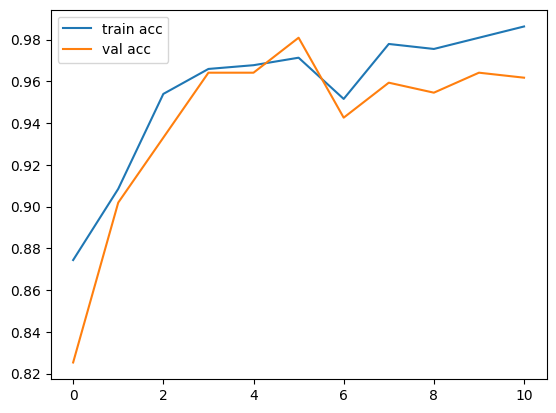

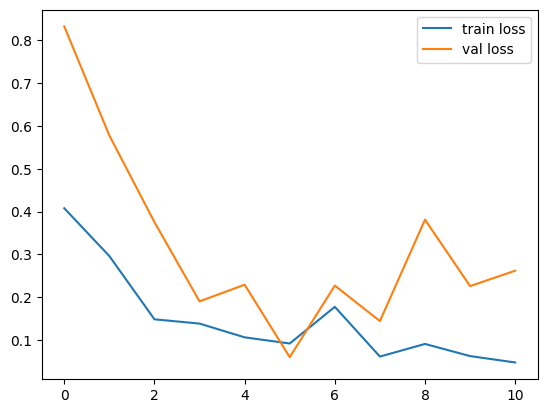

In [ ]:
plt.plot(history_fine.history['accuracy'], label='train acc')
plt.plot(history_fine.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_fine.history['loss'], label='train loss')
plt.plot(history_fine.history['val_loss'], label='val loss')
plt.legend()
plt.show()

### 11.4 Evaluation — Fine-Tuned Model

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

# classNames is already defined globally from os.listdir(train_dir)
# classNames = test_ds.classNames

print(classification_report(y_true, y_pred, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step
              precision    recall  f1-score   support

      aphids       0.98      0.98      0.98        44
    armyworm       1.00      0.95      0.98        43
      beetle       0.96      0.98      0.97        50
    bollworm       0.92      1.00      0.96        36
 grasshopper       1.00      1.00      1.00        46
       mites       1.00      1.00      1.00        42
    mosquito       1.00      0.98      0.99        50
      sawfly       0.97      0.86      0.91        37
  stem_borer       0.90      0.97      0.93        36

    accuracy                           0.97       384
   macro avg       0.97      0.97      0.97       384
weighted avg       0.97      0.97      0.97       384



In [ ]:
finetune_loss, finetune_acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 0.9714 - loss: 0.2592
Test Accuracy: 0.9713541865348816


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

# classNames is already defined globally from os.listdir(train_dir)
print(classification_report(y_true, y_pred, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step
              precision    recall  f1-score   support

      aphids       0.98      0.98      0.98        44
    armyworm       1.00      0.95      0.98        43
      beetle       0.96      0.98      0.97        50
    bollworm       0.92      1.00      0.96        36
 grasshopper       1.00      1.00      1.00        46
       mites       1.00      1.00      1.00        42
    mosquito       1.00      0.98      0.99        50
      sawfly       0.97      0.86      0.91        37
  stem_borer       0.90      0.97      0.93        36

    accuracy                           0.97       384
   macro avg       0.97      0.97      0.97       384
weighted avg       0.97      0.97      0.97       384



---
# Comparative Analysis: All Models

This section provides a comprehensive comparison of all models trained throughout this project.


> Fill in test accuracy values from the classification report outputs above after running the notebook.

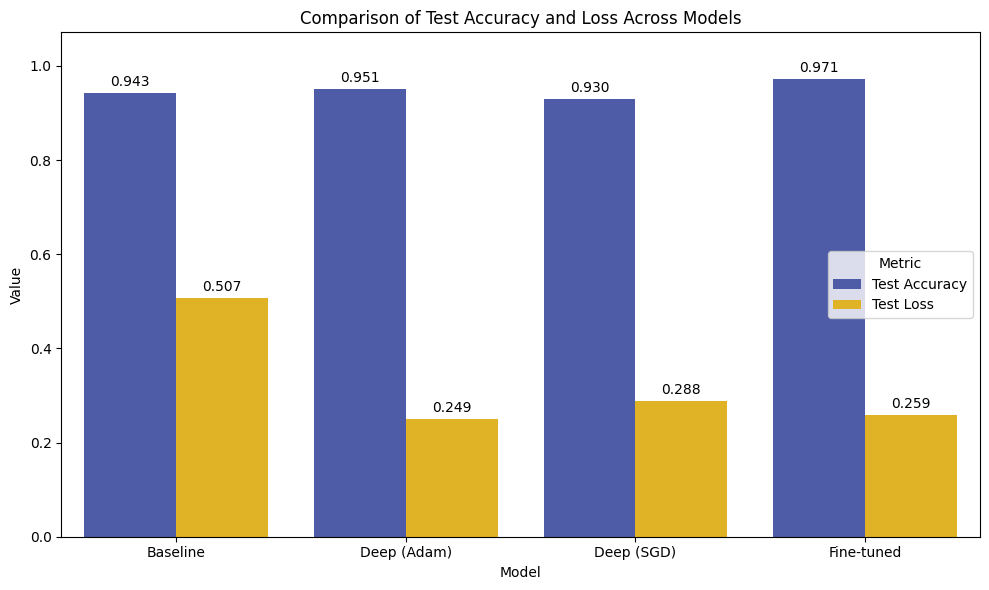

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get the test accuracy and loss for each model
metrics = {
    'Model': ['Baseline', 'Deep (Adam)', 'Deep (SGD)', 'Fine-tuned'],
    'Test Accuracy': [
        baseline_acc,
        deep_acc,
        deep_sgd_acc,
        finetune_acc
    ],
    'Test Loss': [
        baseline_loss,
        deep_loss,
        deep_sgd_loss,
        finetune_loss
    ]
}

metrics_df = pd.DataFrame(metrics)

# Reshape data for a single combined plot
metrics_melted = metrics_df.melt(
    id_vars='Model',
    value_vars=['Test Accuracy', 'Test Loss'],
    var_name='Metric',
    value_name='Value'
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=metrics_melted,
    x='Model',
    y='Value',
    hue='Metric',
    palette=['#3F51B5', '#FFC107']
)

plt.title('Comparison of Test Accuracy and Loss Across Models')
plt.ylabel('Value')
plt.ylim(0, max(metrics_melted['Value']) + 0.1)

# Add value labels on bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f', padding=3)

plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## 12.2 Learning Curve Comparison

The following plot overlays the validation accuracy curves of all scratch-trained models to visually compare convergence behaviour.

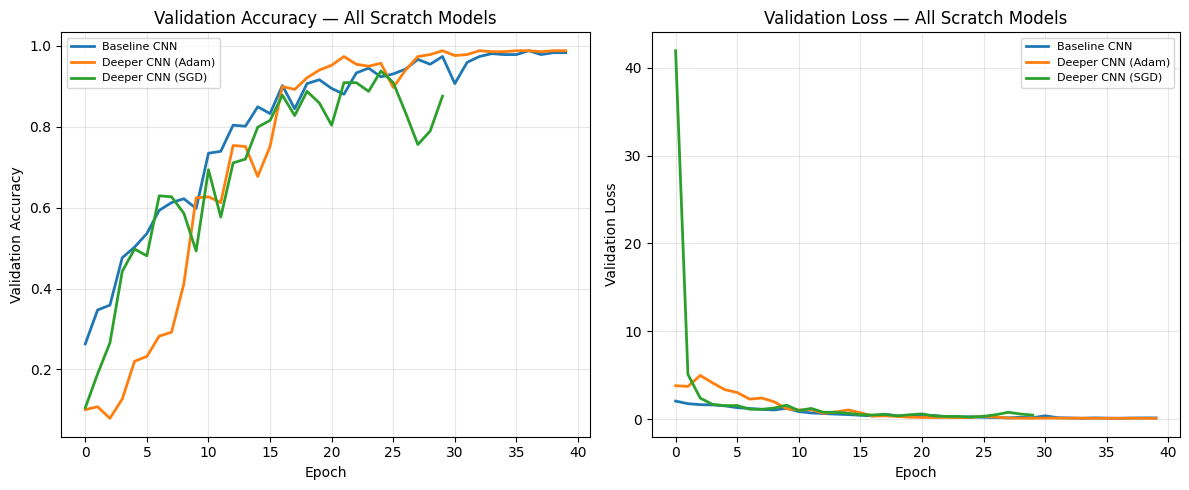

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Validation Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline CNN', linewidth=2)
plt.plot(history_deep.history['val_accuracy'], label='Deeper CNN (Adam)', linewidth=2)
plt.plot(history_sgd.history['val_accuracy'], label='Deeper CNN (SGD)', linewidth=2)

plt.title('Validation Accuracy — All Scratch Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# Validation Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline CNN', linewidth=2)
plt.plot(history_deep.history['val_loss'], label='Deeper CNN (Adam)', linewidth=2)
plt.plot(history_sgd.history['val_loss'], label='Deeper CNN (SGD)', linewidth=2)

plt.title('Validation Loss — All Scratch Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()